<a href="https://colab.research.google.com/github/rd-gabriela/IC-percepcao-temporal/blob/main/GraficosExperimento(github).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/rd-gabriela/IC-percepcao-temporal/refs/heads/main/dados_sujeitos.csv")
df

,Sujeito,tentativa,intervalo_solicitado,intervalo_reproduzido
0,Sujeito_01,2,1.0,1.282
1,Sujeito_01,4,1.0,1.324
2,Sujeito_01,8,1.0,1.443
3,Sujeito_01,10,1.0,1.379
4,Sujeito_01,12,1.0,1.176
...,...,...,...,...
489,Sujeito_11,30,4.0,3.327
490,Sujeito_11,36,4.0,2.774
491,Sujeito_11,38,4.0,3.441
492,Sujeito_11,41,4.0,3.283


In [11]:
#Único sujeito
#sns.lmplot(data= df.query("Sujeito=='Sujeito_01'"), x= "intervalo_solicitado", y= "intervalo_reproduzido", hue='Sujeito')

#Todos os sujeitos
# sns.lmplot(df, x= "intervalo_solicitado", y= "intervalo_reproduzido", hue='Sujeito')
# plt.plot([0,4],[0,4],'k--')

# #Histogramas por intervalo solicitado
# sns.displot(df, x="intervalo_reproduzido", col='Sujeito')
# plt.show()


In [12]:
#Calcular a média e desvio padrão de cada participante, para cada intervalo
mu = df.groupby(["Sujeito", "intervalo_solicitado"]).intervalo_reproduzido.mean().reset_index()
std = df.groupby(["Sujeito", "intervalo_solicitado"]).intervalo_reproduzido.std().reset_index()


#Standard Error (Erro Padrão: dp / sqrt(N))
se = []
N = 11                   #Tamanho da amostra

for i in range(len(std.iloc[:, -1])):
  se.append(std.iloc[:, -1][i] / np.sqrt(N))

se = np.array(se)

#CV (CV = dp / média do participante)
cv = []
for i in range(len(std.iloc[:, -1])):
  cv.append(std.iloc[:, -1][i] / mu.iloc[:, -1][i])

cv = np.array(cv)

In [13]:
df_medias_dps = mu.rename(columns={'intervalo_reproduzido': 'medias'})
df_medias_dps = df_medias_dps.assign(desvio_padrao=std.iloc[:, -1])
df_medias_dps = df_medias_dps.assign(desvio_padrao_da_media=se)
df_medias_dps = df_medias_dps.assign(cv=cv)

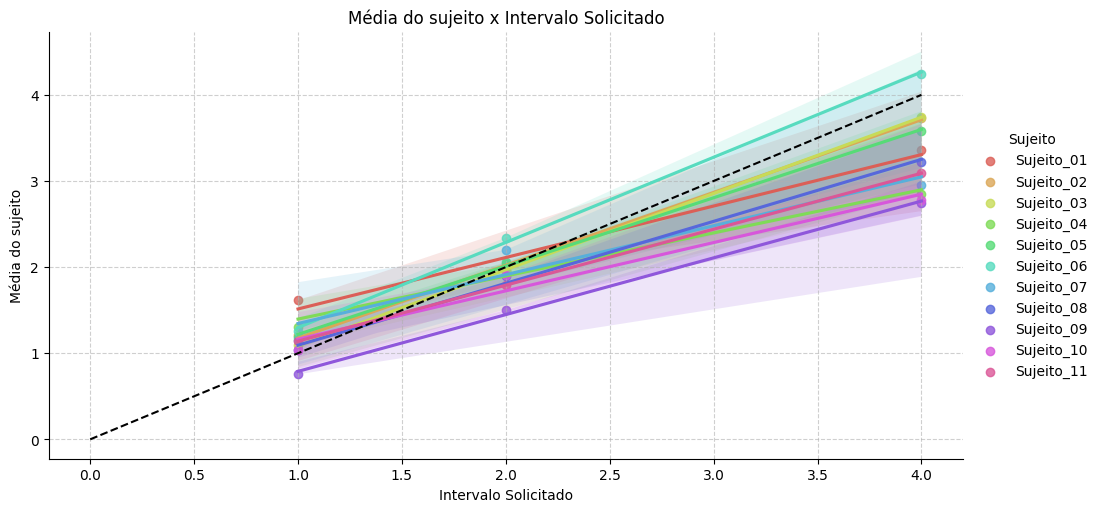

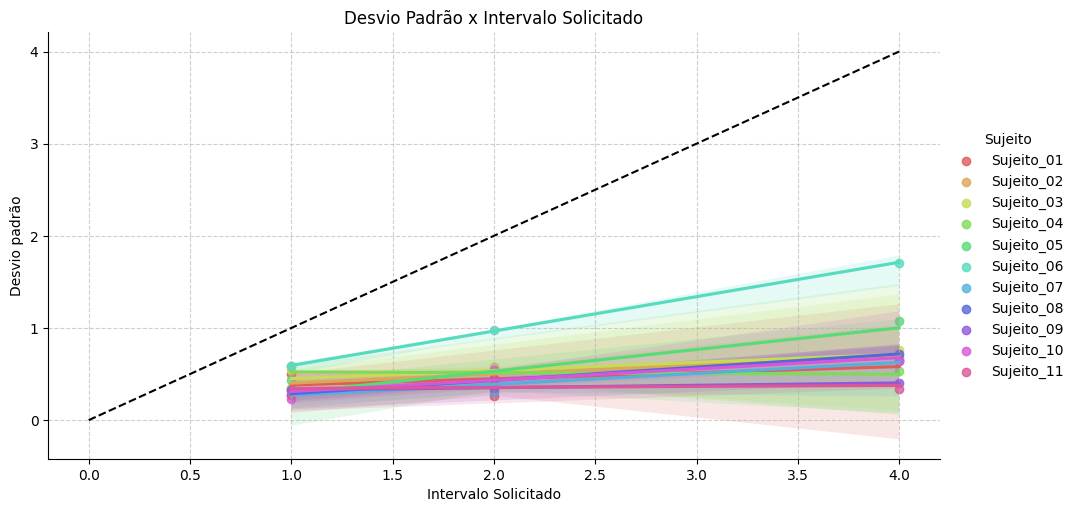

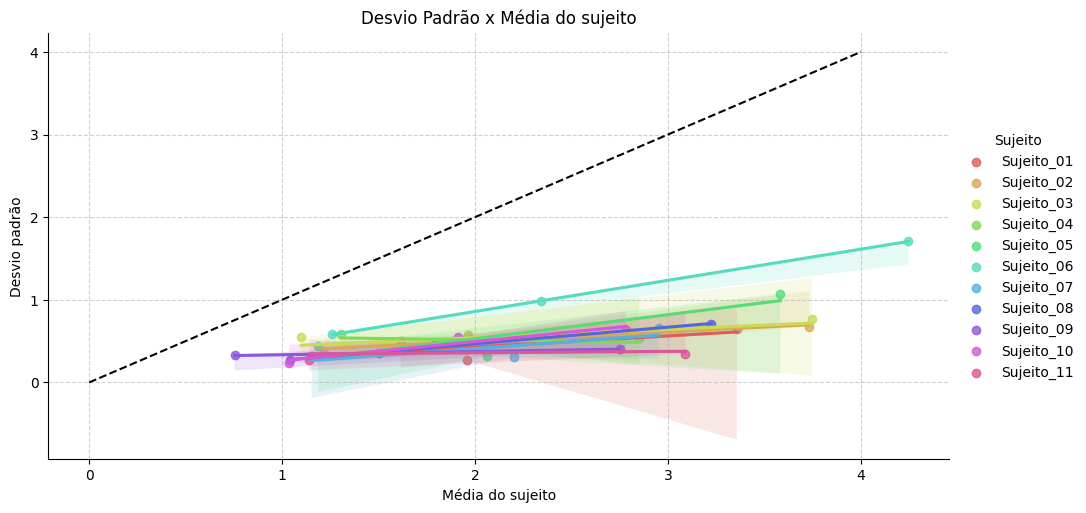

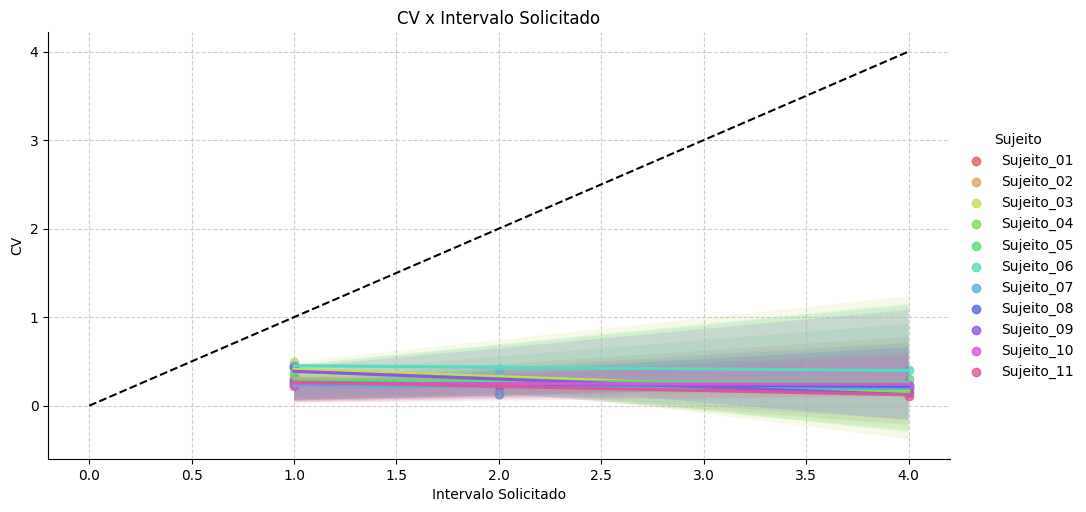

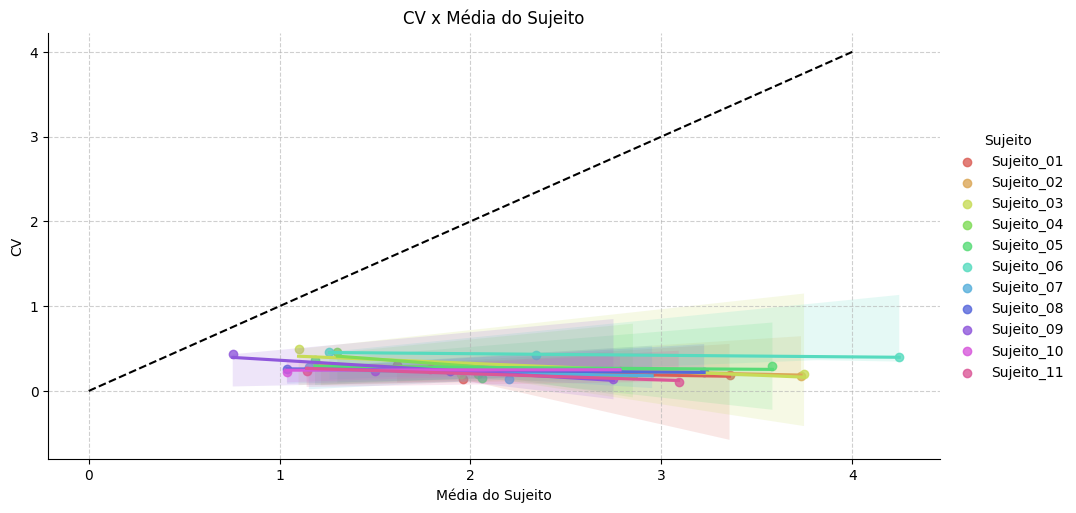

In [16]:
#Desvio Padrão x Média do sujeito
sns.lmplot(df_medias_dps, x='intervalo_solicitado', y='medias', hue='Sujeito', palette='hls', height=5, aspect=2)
plt.title('Média do sujeito x Intervalo Solicitado')
plt.xlabel("Intervalo Solicitado")
plt.ylabel("Média do sujeito")
plt.plot([0,4],[0,4],'k--')
plt.grid(True, linestyle='--', alpha=0.6)

#Desvio Padrão x Intervalo Solicitado
sns.lmplot(df_medias_dps, x='intervalo_solicitado', y='desvio_padrao', hue='Sujeito', palette='hls', height=5, aspect=2)
plt.title('Desvio Padrão x Intervalo Solicitado')
plt.xlabel("Intervalo Solicitado")
plt.ylabel("Desvio padrão")
plt.plot([0,4],[0,4],'k--')
plt.grid(True, linestyle='--', alpha=0.6)

#Desvio Padrão x Média do sujeito
sns.lmplot(df_medias_dps, x='medias', y='desvio_padrao', hue='Sujeito', palette='hls', height=5, aspect=2)
plt.title('Desvio Padrão x Média do sujeito')
plt.xlabel("Média do sujeito")
plt.ylabel("Desvio padrão")
plt.plot([0,4],[0,4],'k--')
plt.grid(True, linestyle='--', alpha=0.6)

#CV x Intervalo Solicitado
sns.lmplot(df_medias_dps, x='intervalo_solicitado', y='cv', hue='Sujeito', palette='hls', height=5, aspect=2)
plt.title('CV x Intervalo Solicitado')
plt.xlabel("Intervalo Solicitado")
plt.ylabel("CV")
plt.plot([0,4],[0,4],'k--')
plt.grid(True, linestyle='--', alpha=0.6)

#CV x Média
sns.lmplot(df_medias_dps, x='medias', y='cv', hue='Sujeito', palette='hls', height=5, aspect=2)
plt.title('CV x Média do Sujeito')
plt.xlabel("Média do Sujeito")
plt.ylabel("CV")
plt.plot([0,4],[0,4],'k--')
plt.grid(True, linestyle='--', alpha=0.6)